# Phase 5: Customer Segmentation & Clustering (K-Means & PCA)

## 1. Unsupervised Segmentation
In this phase, we group prospective plot buyers using **K-Means Clustering** and visualize clusters using **Principal Component Analysis (PCA)**.
Buyer personas identified:
1. **Affluent Luxury Investors**
2. **High-Intent Mid-Career Upgraders**
3. **Young Starter Buyers**
4. **Conservative Value Seekers**


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

clean_path = os.path.join("..", "data", "real_estate_clean.csv")
df = pd.read_csv(clean_path)

features = [
    "Age", "Monthly_Income", "Plot_Budget",
    "Preferred_Plot_Size_SqFt", "Distance_to_City_Center_km",
    "Purchase_Probability"
]

X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features standardized.")


Features standardized.


## 2. Elbow Method for Optimal Clusters

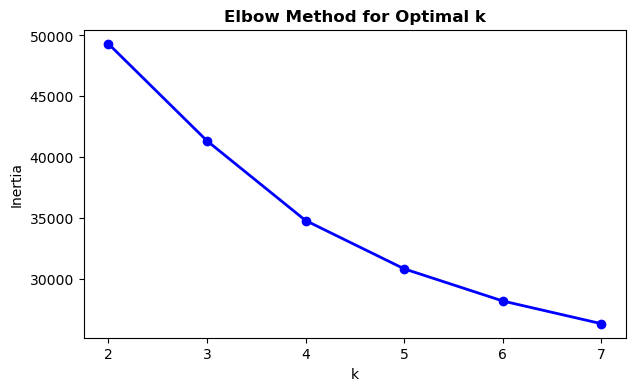

In [2]:
inertias = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertias, 'bo-', linewidth=2)
plt.title("Elbow Method for Optimal k", fontweight='bold')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()


## 3. Fitting K-Means (k=4) & Profiling Personas

In [3]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_summary = df.groupby('Cluster')[features].mean().round(2)
print("Centroid Summary:")
print(cluster_summary)

persona_map = {}
for c in range(4):
    if cluster_summary.loc[c, 'Plot_Budget'] > 12000000:
        persona_map[c] = "Affluent Luxury Investors"
    elif cluster_summary.loc[c, 'Purchase_Probability'] > 0.55:
        persona_map[c] = "High-Intent Mid-Career Upgraders"
    elif cluster_summary.loc[c, 'Age'] < 30:
        persona_map[c] = "Young Starter Buyers"
    else:
        persona_map[c] = "Conservative Value Seekers"

df['Persona'] = df['Cluster'].map(persona_map)
print("\nPersona Distribution (%):")
print(df['Persona'].value_counts(normalize=True).round(3) * 100)


Centroid Summary:
           Age  Monthly_Income  Plot_Budget  Preferred_Plot_Size_SqFt  \
Cluster                                                                 
0        48.33       200214.20   9083825.95                   1608.40   
1        32.24        79881.01   3702132.19                   1010.76   
2        50.25       433251.60  20742327.13                   2757.31   
3        35.02        94079.75   4260463.38                   1076.80   

         Distance_to_City_Center_km  Purchase_Probability  
Cluster                                                    
0                             23.29                  0.36  
1                             24.13                  0.18  
2                             24.15                  0.40  
3                             22.37                  0.85  

Persona Distribution (%):
Persona
Conservative Value Seekers          68.0
High-Intent Mid-Career Upgraders    25.7
Affluent Luxury Investors            6.3
Name: proportion, dtype: 

## 4. PCA 2D Cluster Projection

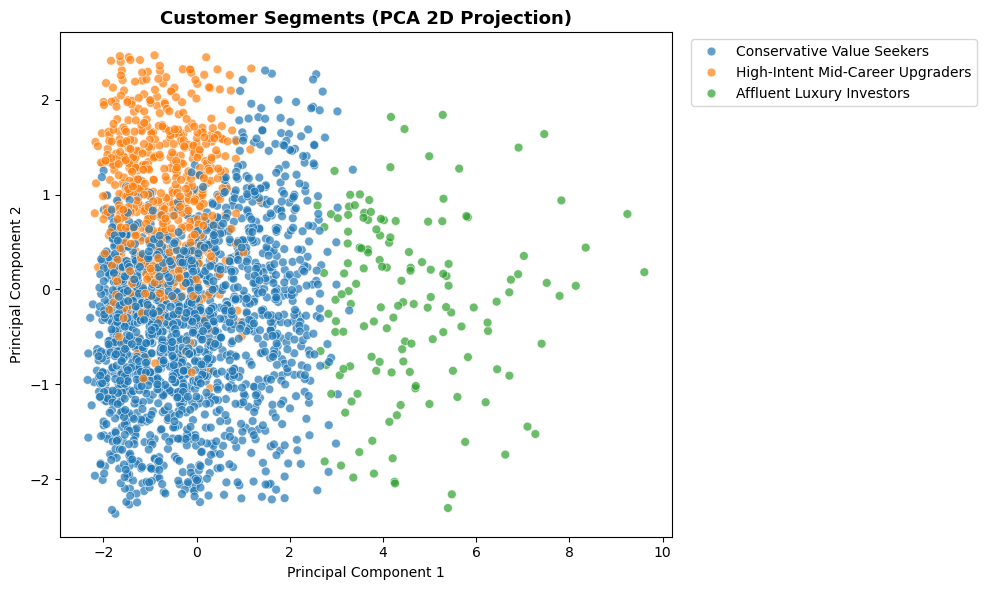

In [4]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df.sample(2500, random_state=42),
    x='PCA1',
    y='PCA2',
    hue='Persona',
    palette='tab10',
    alpha=0.7,
    s=40
)
plt.title("Customer Segments (PCA 2D Projection)", fontsize=13, fontweight='bold')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()
